In [1]:
# using MKL, MKLSparse
# MKL.BLAS.set_num_threads(1)
using LinearAlgebra
include("../Landau level torus.jl")
using .LLT
using CairoMakie
function plot_ed_spectrum(energies, ss_k, Gk::NTuple{2, Int64};
    title = nothing, ylims = (nothing, nothing),
    ylabel = "Energy per unit cell (W₀ = e²/ϵl)",
    top_subspace_number = true)

    fig = Figure();
    ax = Axis(fig[1, 1];
        xlabel = "k1+$(Gk[1])k2",
        ylabel = ylabel
    )
    ax_top = Axis(fig[1, 1];
        xaxisposition = :top
    )
    top_ticks = ([], [])
    hidespines!(ax_top)
    hidexdecorations!(ax_top; label = false, ticklabels = false)
    hideydecorations!(ax_top)
    linkxaxes!(ax, ax_top)

    # Plot energy levels for each momentum block
    for i in eachindex(ss_k)
        x = ss_k[i][1] + Gk[1] * ss_k[i][2]
        push!(top_ticks[1], x)
        push!(top_ticks[2], string(i))
        if isassigned(energies,i)
            for e in energies[i]
                scatter!(ax, x, e, color = :blue, marker=:hline)
            end
        end
    end
    ylims!(ax, ylims...)
    top_subspace_number && (ax_top.xticks = top_ticks)
    if title isa String
        ax_top.subtitle = title
    end
    display(fig)
    fig, ax
end

plot_ed_spectrum (generic function with 1 method)

In [2]:
using MomentumED
using CUDA
MomentumED.Methods.GPU_AVAILABLE[:cuda][] # true if CUDA is available

┌ Info: MomentumED CUDA extension loaded.
└ @ MomentumEDCUDAExt e:\MomentumED.jl\MomentumED\ext\MomentumEDCUDAExt.jl:19


true

In [3]:
# preparation for 1/3 filling with 12 electrons in 36 orbitals
# subspace momentum decomposition will cost many minutes, althrough accelerated with multiple CPU threads
# will need 10GB VRAM if using krylov_dim = 20 (default value is 30)

k_list = [0 1 2 3 0 1 2 3 0 1 2 3 0 1 2 3 0 1 2 3 0 1 2 3;
          0 0 0 0 1 1 1 1 2 2 2 2 3 3 3 3 4 4 4 4 5 5 5 5]
Nk = 24
Gk = (4, 6)
Ne = 8

8

In [4]:
# preparation for 1/3 filling with 12 electrons in 36 orbitals
# subspace momentum decomposition will cost many minutes, althrough accelerated with multiple CPU threads
# will need 10GB VRAM if using krylov_dim = 20 (default value is 30)

#=
k_list = [0 1 2 3 4 5 0 1 2 3 4 5 0 1 2 3 4 5 0 1 2 3 4 5 0 1 2 3 4 5 0 1 2 3 4 5;
          0 0 0 0 0 0 1 1 1 1 1 1 2 2 2 2 2 2 3 3 3 3 3 3 4 4 4 4 4 4 5 5 5 5 5 5]
Nk = 36
Gk = (6, 6)
Ne = 12
=#

In [5]:
tri_lattice = ReciprocalLattice(:triangular)
sys_int = LandauInteraction(tri_lattice, (1, 0, 1, 0))
sys_int.D_l = 10.0
sys_int.mix = 0          # mix * Haldane + (1-mix) * Coulomb
para = EDPara(; k_list, Gk, H_two = sys_int);
@time subspaces, ss_k = ED_momentum_subspaces(para, Ne);
display(collect(zip(length.(subspaces), ss_k)))
scat = ED_scatterlist_twobody(para);
hmlt = MBOperator(scat, upper_hermitian = true)

24-element Vector{Tuple{Int64, Tuple{Int64, Int64}}}:
 (30709, (0, 0))
 (30624, (1, 0))
 (30704, (2, 0))
 (30624, (3, 0))
 (30624, (0, 1))
 (30624, (1, 1))
 (30624, (2, 1))
 (30624, (3, 1))
 (30709, (0, 2))
 (30624, (1, 2))
 ⋮
 (30624, (3, 3))
 (30709, (0, 4))
 (30624, (1, 4))
 (30704, (2, 4))
 (30624, (3, 4))
 (30624, (0, 5))
 (30624, (1, 5))
 (30624, (2, 5))
 (30624, (3, 5))

  2.360221 seconds (33.98 M allocations: 1.387 GiB, 12.35% gc time, 530.56% compilation time)


Many Body Operator (Hermitian, upper triangle entries only) :
	Vector{EDCore.Scatter{ComplexF64, MBS64{24}}} with 1734 scattering terms


In [6]:
MomentumED.release_gpu_memory(Val(:cuda))        # clean up GPU memory
# output the gpu memory at the peaks, default to be true
MomentumED.GPU_MEMORY_MONITOR[] = false

false

In [7]:
# for Nk = 6×6, the 3 ground states are all in the first momentum sector (0,0)
Neigen = 9  # Number of eigenvalues to compute per subspace
ss_range = 1:24
# ss_range = 1:36
energies = [Vector{Float64}() for _ in ss_range];
vectors = Vector{Vector{<:MBS64Vector}}(undef, length(ss_range));
for i in eachindex(ss_range)
    println("Processing subspace #$i with size $(length(subspaces[ss_range[i]])), momentum $(ss_k[ss_range[i]])")
    energies[i], vectors[i] = EDsolve(subspaces[ss_range[i]], hmlt;
        N = Neigen, showtime = true, ishermitian = true,
        # method = :sparse, device = :cpu,            # sparse matrix method in cpu
        # method = :sparse, device = :cuda,           # sparse matrix method in cuda
        # method = :map, device = :cpu,               # linear map method in cpu (will be slow for large size)
        method = :map, device = :cuda,              # linear map method in CUDA gpu
        # krylovdim = 20,               # default 30, determines the memory usage
        # verbosity = 4,                 # show krylov-schur algorithm details
    )
end

Processing subspace #1 with size 30709, momentum (0, 0)
 17.523603 seconds (23.48 M allocations: 1.097 GiB, 17.88% gc time, 2 lock conflicts, 61.92% compilation time: 7% of which was recompilation)
Processing subspace #2 with size 30624, momentum (1, 0)
  6.117437 seconds (1.12 M allocations: 20.838 MiB, 56.08% gc time, 0.06% compilation time)
Processing subspace #3 with size 30704, momentum (2, 0)
  4.574440 seconds (862.10 k allocations: 16.042 MiB, 53.17% gc time, 1 lock conflict)
Processing subspace #4 with size 30624, momentum (3, 0)
  6.108382 seconds (1.08 M allocations: 20.230 MiB, 55.44% gc time, 2 lock conflicts)
Processing subspace #5 with size 30624, momentum (0, 1)
  9.276910 seconds (1.58 M allocations: 29.442 MiB, 54.45% gc time, 1 lock conflict)
Processing subspace #6 with size 30624, momentum (1, 1)
  5.307337 seconds (916.76 k allocations: 17.200 MiB, 52.88% gc time, 1 lock conflict)
Processing subspace #7 with size 30624, momentum (2, 1)
  4.698161 seconds (863.01 k 

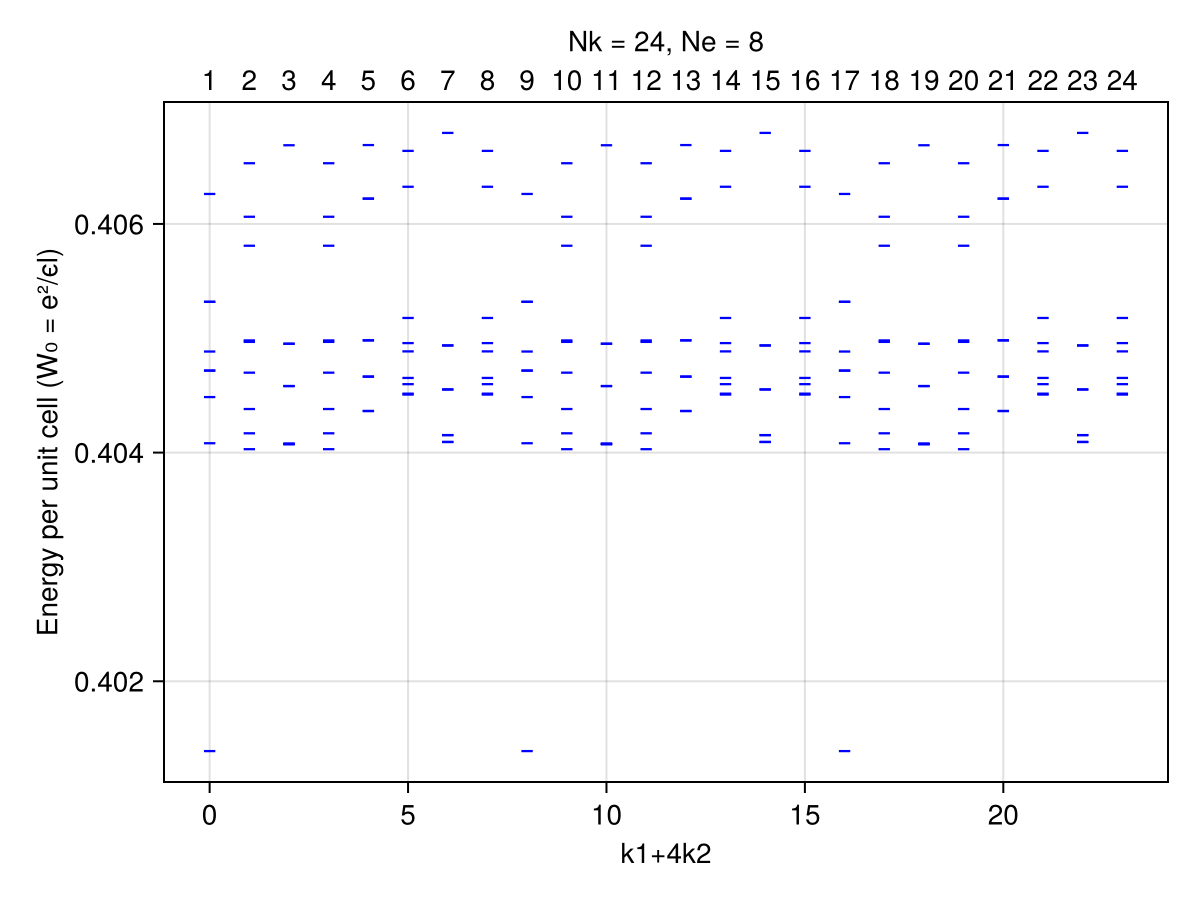

In [8]:
plot_ed_spectrum(energies/Nk/LLT.W0, ss_k[ss_range], Gk;
    title = "Nk = $Nk, Ne = $Ne",
);